In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftshift

C = 3e8
FS = 10e6
FC = 2.4e9
LAMBDA = C / FC
PRI = 1e-3
N_PULSES = 64

N_SC = 64
CP = 16

In [2]:
def generate_ofdm():
    data = (np.random.randint(0,2,N_SC)*2-1) + 1j*(np.random.randint(0,2,N_SC)*2-1)
    ofdm = ifft(data)
    cp = ofdm[-CP:]
    signal = np.concatenate([cp, ofdm])
    return signal / np.sqrt(np.mean(np.abs(signal)**2))

In [3]:
def simulate(targets, SNR_dB=20):
    ref = []
    surv = []

    for p in range(N_PULSES):
        sig = generate_ofdm()
        ref.append(sig)

        echo = np.zeros_like(sig, dtype=complex)

        for t in targets:
            delay = int((2*t['R']/C)*FS)
            fd = 2*t['v']/LAMBDA

            doppler = np.exp(1j*2*np.pi*fd*p*PRI)
            shifted = np.roll(sig, delay) * doppler * t['amp']

            echo += shifted

        signal_power = np.mean(np.abs(sig)**2)
        noise_power = signal_power / (10**(SNR_dB/10))

        noise = np.sqrt(noise_power/2) * (np.random.randn(*sig.shape) + 1j*np.random.randn(*sig.shape))

        surv.append(0.3*sig + echo + noise)

    return np.array(ref), np.array(surv)

In [4]:
def process(ref, surv):
    corr = fft(surv, axis=1) * np.conj(fft(ref, axis=1))
    window = np.hanning(ref.shape[1])
    corr *= window
    corr = ifft(corr, axis=1)

    mti = corr[1:] - corr[:-1]

    rd = fftshift(fft(mti, axis=0), axes=0)
    return rd

In [5]:
def axes(rd):
    rng_bins = rd.shape[1]
    doppler_bins = rd.shape[0]

    ranges = np.arange(rng_bins) * (C/(2*FS))
    doppler = np.linspace(-1/(2*PRI), 1/(2*PRI), doppler_bins)

    return ranges, doppler

In [9]:
def detect(rd):
    power = np.abs(rd)**2
    threshold = np.mean(power) + 3*np.std(power)
    det = power > threshold
    det = det & (power > np.max(power)*0.3)
    return det


In [10]:
def visualize_all(ref, surv, rd, det, name):
    ranges, doppler = axes(rd)

    fig = plt.figure(figsize=(14,10))

    # 1. Time Domain
    ax1 = plt.subplot(2,3,1)
    ax1.plot(np.real(ref[0]), label="Reference")
    ax1.plot(np.real(surv[0]), label="Surveillance", alpha=0.7)
    ax1.set_title("Time Domain")
    ax1.legend()

    # 2. Frequency Spectrum
    ax2 = plt.subplot(2,3,2)
    ax2.psd(ref.flatten(), Fs=FS)
    ax2.set_title("Frequency Spectrum")

    # 3. Range-Doppler BEFORE MTI
    corr = ifft(fft(surv, axis=1) * np.conj(fft(ref, axis=1)), axis=1)
    rd_before = fftshift(fft(corr, axis=0), axes=0)

    ax3 = plt.subplot(2,3,3)
    ax3.imshow(20*np.log10(np.abs(rd_before)+1e-6), aspect='auto')
    ax3.set_title("Before MTI")

    # 4. Range-Doppler AFTER MTI
    ax4 = plt.subplot(2,3,4)
    ax4.imshow(20*np.log10(np.abs(rd)+1e-6),
               aspect='auto',
               extent=[ranges[0], ranges[-1], doppler[0], doppler[-1]])
    ax4.set_title("After MTI")

    # 5. 3D Surface
    ax5 = plt.subplot(2,3,5, projection='3d')
    X, Y = np.meshgrid(ranges, doppler)
    Z = 20*np.log10(np.abs(rd)+1e-6)
    ax5.plot_surface(X, Y, Z, cmap='viridis')
    ax5.set_title("3D Surface")

    # 6. Detection Map
    ax6 = plt.subplot(2,3,6)
    ax6.imshow(det, aspect='auto',
               extent=[ranges[0], ranges[-1], doppler[0], doppler[-1]])
    ax6.set_title("Detection Map")

    plt.suptitle(name)
    plt.tight_layout()
    plt.show()

In [11]:
def run(name, targets):
    ref, surv = simulate(targets)
    rd = process(ref, surv)
    det = detect(rd)

    ranges, doppler = axes(rd)

    print(f"\n=== {name} ===")

    print("Max Power:", np.max(np.abs(rd)))
    print("Mean Power:", np.mean(np.abs(rd)))

    print("Detections:", np.sum(det))

    visualize_all(ref, surv, rd, det, name)


=== Clear Sky ===
Max Power: 45.0266051373767
Mean Power: 8.610405383917584
Detections: 115


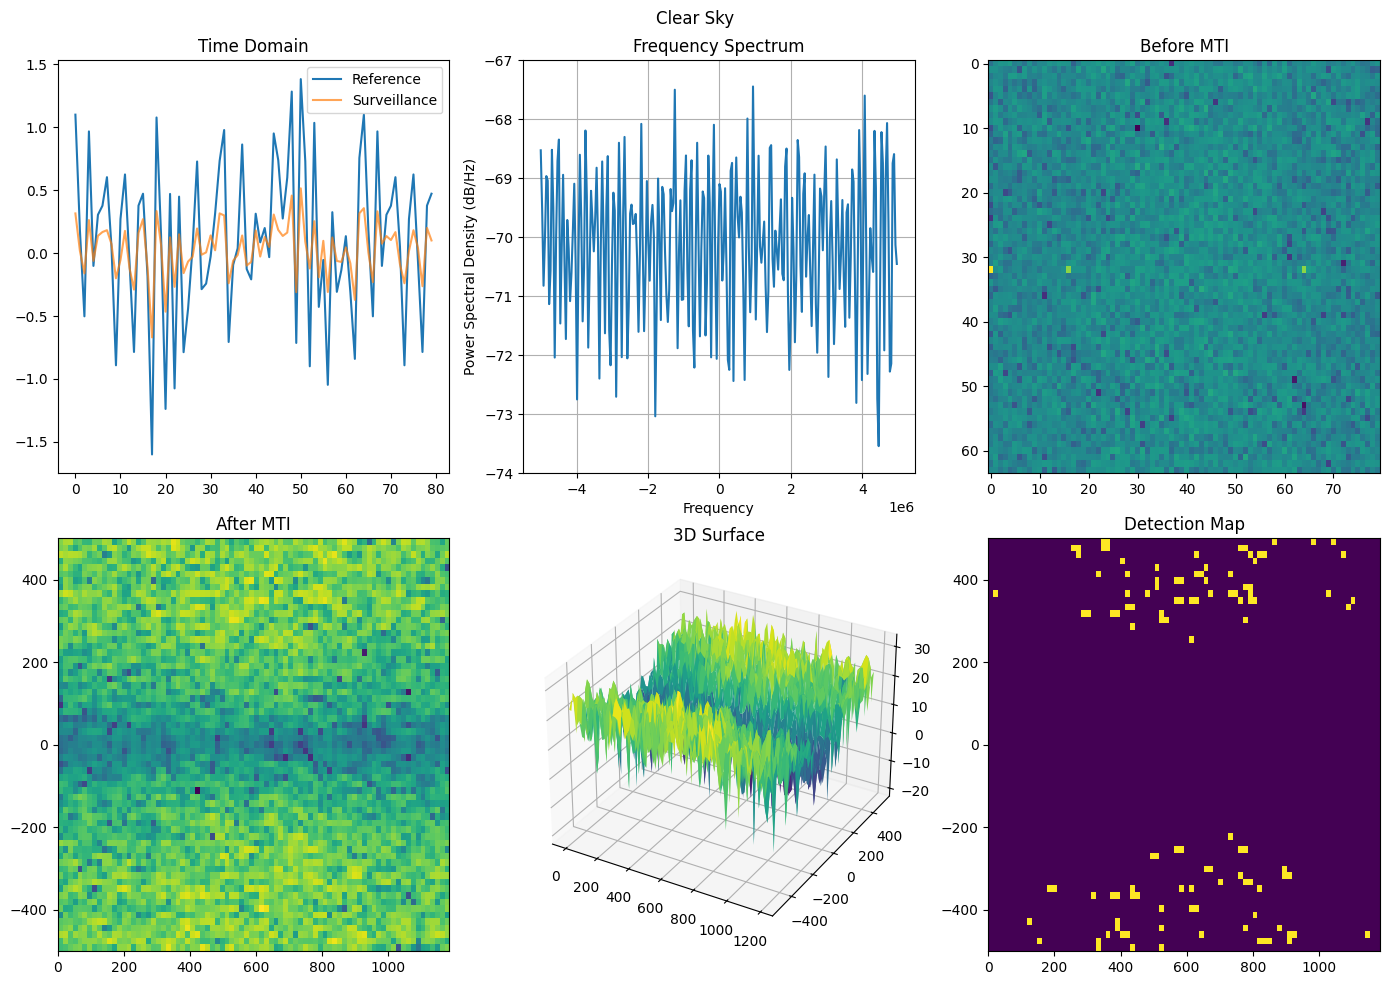

In [12]:
run("Clear Sky", [])


=== Slow Drone ===
Max Power: 449.8671631581757
Mean Power: 17.095298273859253
Detections: 1


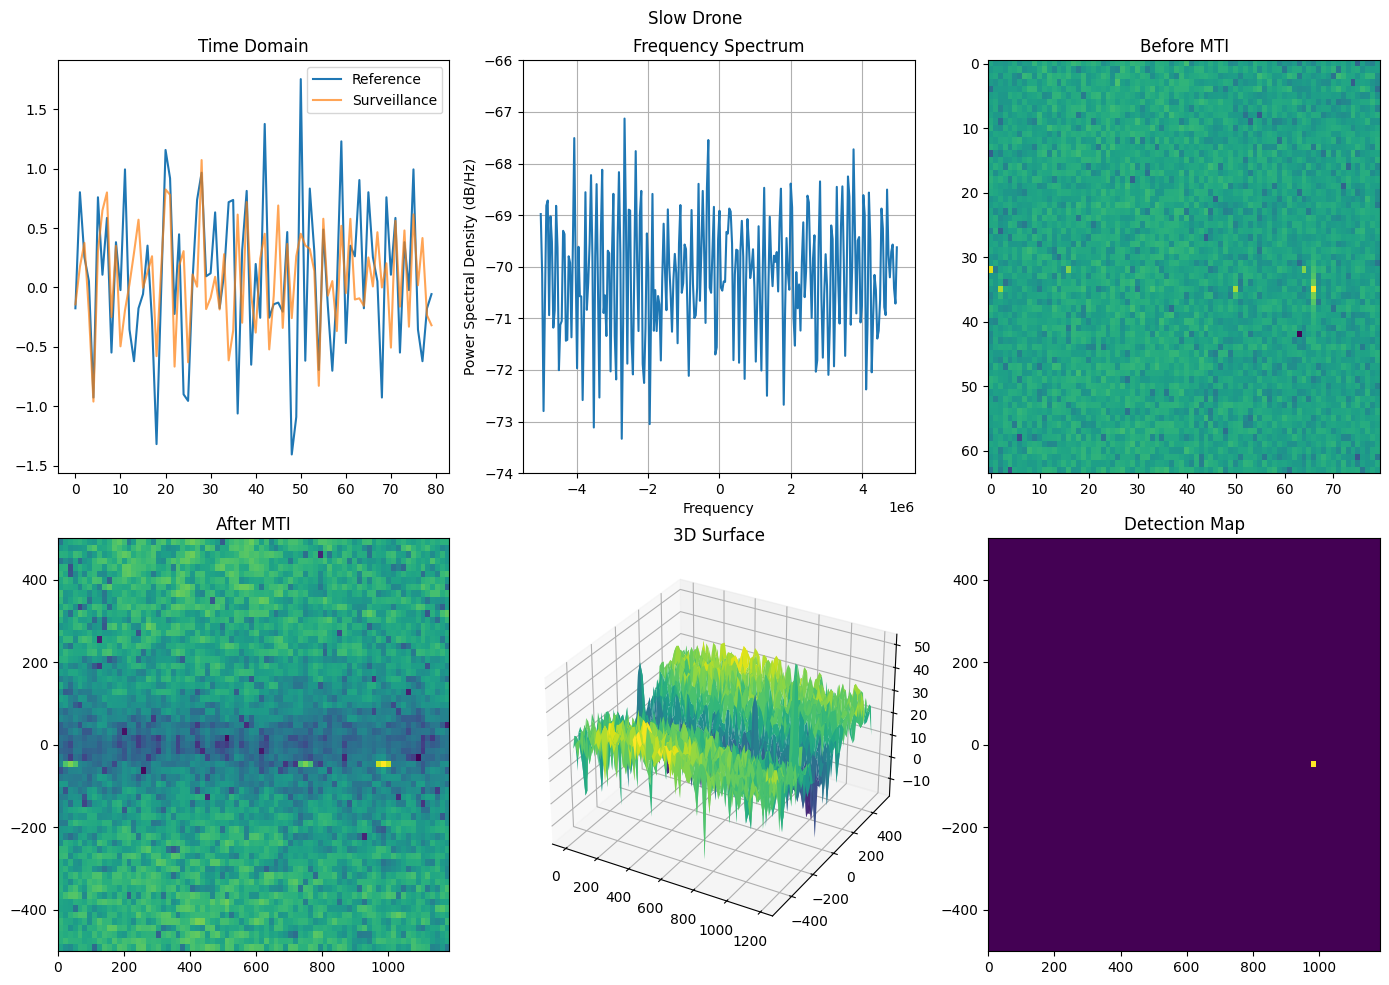

In [13]:
run("Slow Drone", [{"R":1000, "v":3, "amp":0.6}])


=== Fast Drone ===
Max Power: 2699.5612174669404
Mean Power: 20.40551729073714
Detections: 1


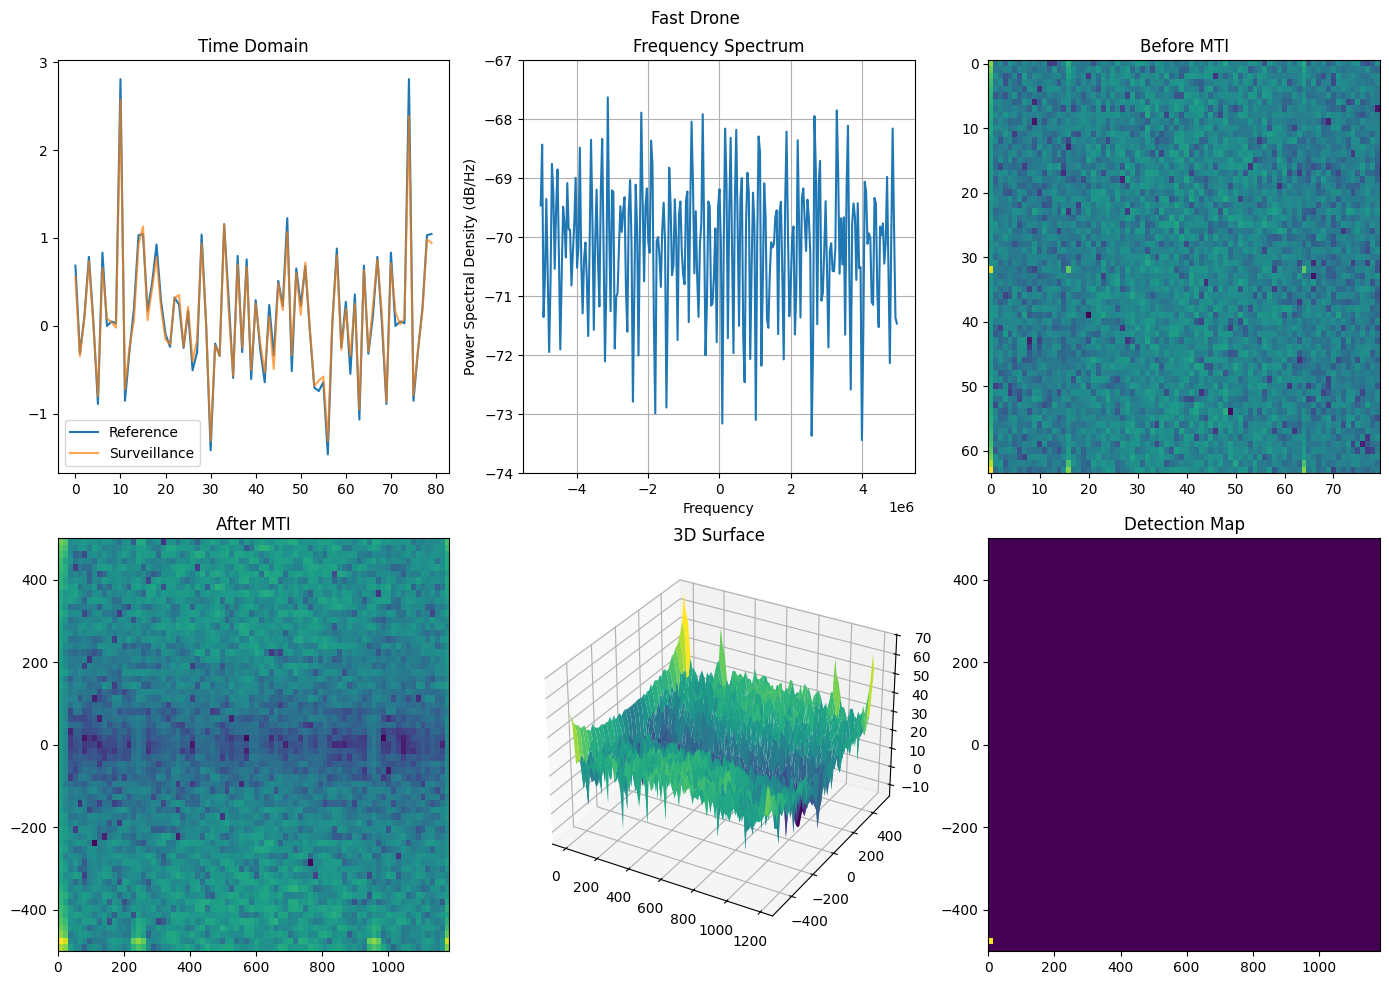

In [14]:
run("Fast Drone", [{"R":1200, "v":30, "amp":0.6}])


=== Swarm ===
Max Power: 1320.6142453517873
Mean Power: 21.427462024935412
Detections: 3


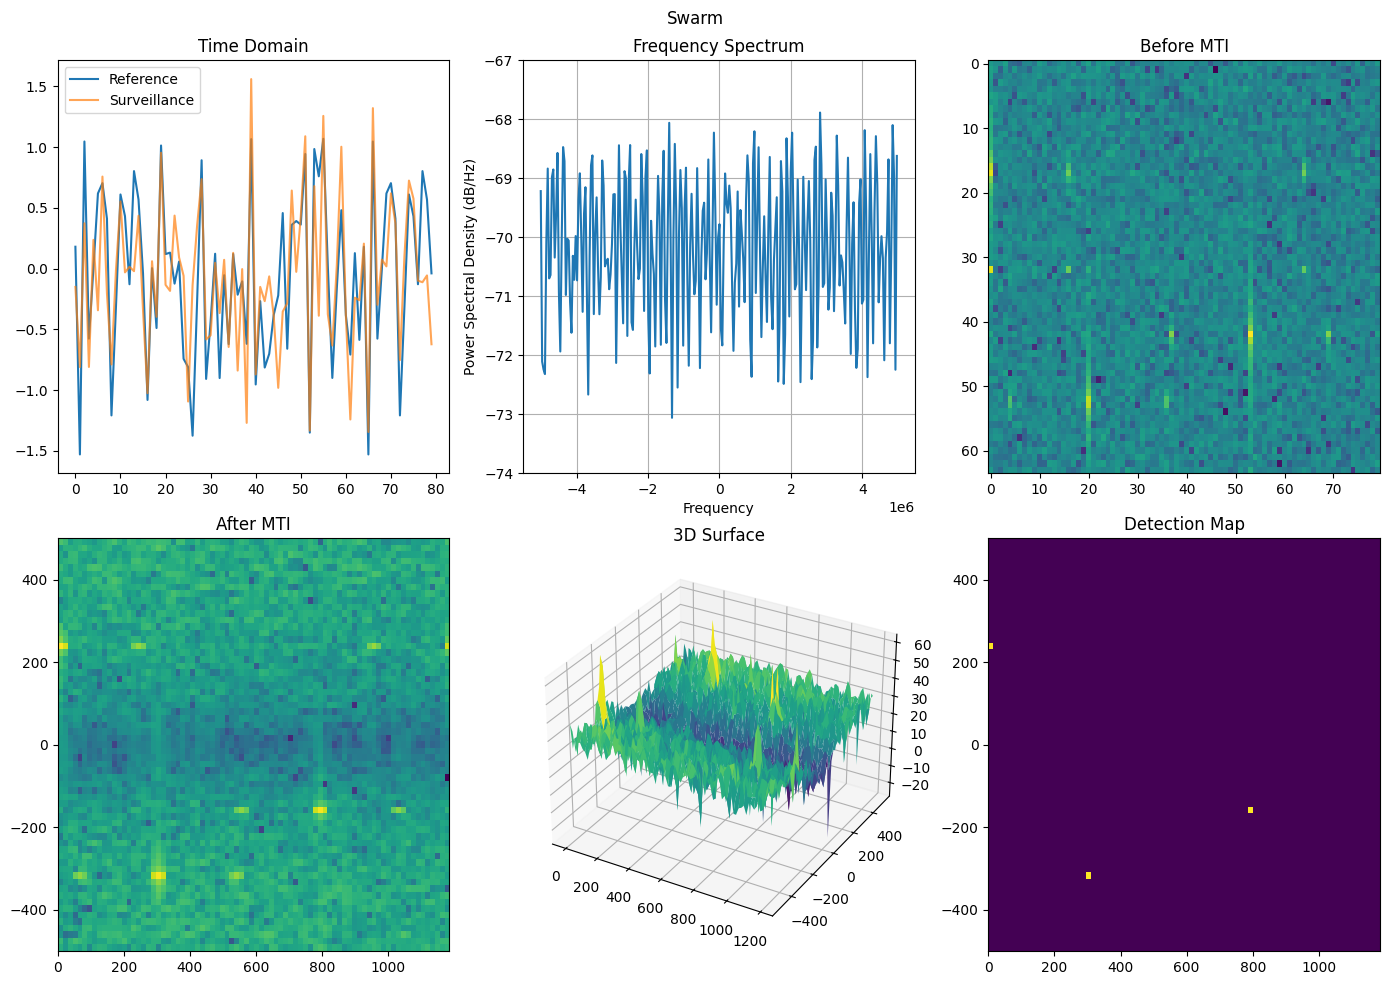

In [15]:
run("Swarm", [
    {"R":800, "v":10, "amp":0.5},
    {"R":1200, "v":-15, "amp":0.4},
    {"R":1500, "v":20, "amp":0.3}
])